In [1]:
# Import libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('..')
from src.mining.association import AssociationRuleMiner
from src.visualization.plots import Visualizer

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load clean text data
print("="*60)
print("LOADING CLEAN DATA")
print("="*60)

train_path = '../data/processed/train_clean.csv'
if os.path.exists(train_path):
    df_train = pd.read_csv(train_path)
    print(f"✅ Loaded training data: {df_train.shape}")
else:
    print("❌ Clean data not found. Please run Notebook 02 first.")

LOADING CLEAN DATA
✅ Loaded training data: (10000, 7)


In [3]:
# Prepare transactions for positive reviews
print("="*60)
print("PREPARING TRANSACTIONS - POSITIVE REVIEWS")
print("="*60)

# Get positive reviews
positive_df = df_train[df_train['label'] == 2].copy()
positive_texts = positive_df['review_clean'].tolist()

print(f"📊 Number of positive reviews: {len(positive_texts):,}")

# Convert each review to a list of words (transaction)
positive_transactions = [text.split() for text in positive_texts]

# Show sample transactions
print("\n📋 Sample transactions:")
for i, trans in enumerate(positive_transactions[:3]):
    print(f"\nTransaction {i+1} ({len(trans)} items):")
    print(f"  {trans[:10]}...")

PREPARING TRANSACTIONS - POSITIVE REVIEWS
📊 Number of positive reviews: 4,903

📋 Sample transactions:

Transaction 1 (40 items):
  ['sound', 'track', 'beauti', 'paint', 'seneri', 'mind', 'well', 'would', 'recomend', 'even']...

Transaction 2 (45 items):
  ['im', 'read', 'lot', 'review', 'say', 'best', 'game', 'soundtrack', 'figur', 'id']...

Transaction 3 (72 items):
  ['soundtrack', 'favorit', 'music', 'time', 'hand', 'intens', 'sad', 'prison', 'fate', 'mean']...


In [4]:
# Filter words by frequency
print("="*60)
print("FILTERING WORDS BY FREQUENCY")
print("="*60)

# Count word frequencies
word_freq = {}
for trans in positive_transactions:
    for word in set(trans):  # Use set to avoid counting duplicates in same review
        word_freq[word] = word_freq.get(word, 0) + 1

# Get top words
min_word_freq = 5
top_words = {word: freq for word, freq in word_freq.items() if freq >= min_word_freq}
top_words_sorted = sorted(top_words.items(), key=lambda x: x[1], reverse=True)

print(f"\n📊 Word frequency statistics:")
print(f"  • Total unique words: {len(word_freq):,}")
print(f"  • Words with frequency >= {min_word_freq}: {len(top_words):,}")

print("\n📊 Top 20 most frequent words:")
for i, (word, freq) in enumerate(top_words_sorted[:20], 1):
    print(f"  {i:2d}. {word:15} : {freq:,} times")

# Filter transactions
top_words_set = set(top_words.keys())
filtered_transactions = []
for trans in positive_transactions:
    filtered = [word for word in trans if word in top_words_set]
    if len(filtered) >= 2:  # Keep only transactions with at least 2 items
        filtered_transactions.append(list(set(filtered)))  # Remove duplicates

print(f"\n📊 After filtering:")
print(f"  • Original transactions: {len(positive_transactions):,}")
print(f"  • Filtered transactions: {len(filtered_transactions):,}")

FILTERING WORDS BY FREQUENCY

📊 Word frequency statistics:
  • Total unique words: 18,234
  • Words with frequency >= 5: 3,621

📊 Top 20 most frequent words:
   1. book            : 1,631 times
   2. one             : 1,342 times
   3. great           : 1,197 times
   4. read            : 1,138 times
   5. like            : 1,098 times
   6. good            : 990 times
   7. love            : 947 times
   8. time            : 918 times
   9. get             : 817 times
  10. would           : 784 times
  11. well            : 693 times
  12. make            : 673 times
  13. use             : 664 times
  14. realli          : 659 times
  15. work            : 618 times
  16. movi            : 587 times
  17. first           : 583 times
  18. stori           : 582 times
  19. recommend       : 582 times
  20. much            : 548 times

📊 After filtering:
  • Original transactions: 4,903
  • Filtered transactions: 4,903


In [5]:
# Encode transactions to one-hot format
print("="*60)
print("ENCODING TRANSACTIONS")
print("="*60)

# Use TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(filtered_transactions).transform(filtered_transactions)
onehot_df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"📊 One-hot encoded dataframe shape: {onehot_df.shape}")
print(f"📊 Sparsity: {(onehot_df == 0).sum().sum() / onehot_df.size:.2%} zeros")

# Show sample
print("\n📋 Sample of one-hot encoded data (first 5 rows, first 10 columns):")
onehot_df.iloc[:5, :10]

ENCODING TRANSACTIONS
📊 One-hot encoded dataframe shape: (4903, 3621)


📊 Sparsity: 99.23% zeros

📋 Sample of one-hot encoded data (first 5 rows, first 10 columns):


,abc,abil,abl,abroad,absolut,absolutli,absorb,absurd,abund,abus
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False


In [6]:
# Mine frequent itemsets with Apriori
print("="*60)
print("APRIORI - FREQUENT ITEMSETS")
print("="*60)

min_support = 0.01  # Minimum support threshold

frequent_itemsets = apriori(
    onehot_df,
    min_support=min_support,
    use_colnames=True,
    max_len=3
)

print(f"📊 Found {len(frequent_itemsets):,} frequent itemsets")
print(f"\n📊 Itemsets by length:")
for i in range(1, 4):
    count = len(frequent_itemsets[frequent_itemsets['itemsets'].apply(len) == i])
    print(f"  • Length {i}: {count:,} itemsets")

# Show top itemsets by support
print("\n📊 Top 10 frequent itemsets by support:")
top_itemsets = frequent_itemsets.nlargest(10, 'support')
for i, (_, row) in enumerate(top_itemsets.iterrows(), 1):
    items = ', '.join(list(row['itemsets']))
    print(f"  {i:2d}. {items[:50]}... : support={row['support']:.4f}")

APRIORI - FREQUENT ITEMSETS


📊 Found 2,951 frequent itemsets

📊 Itemsets by length:
  • Length 1: 598 itemsets
  • Length 2: 1,915 itemsets
  • Length 3: 438 itemsets

📊 Top 10 frequent itemsets by support:
   1. book... : support=0.3327
   2. one... : support=0.2737
   3. great... : support=0.2441
   4. read... : support=0.2321
   5. like... : support=0.2239
   6. good... : support=0.2019
   7. love... : support=0.1931
   8. time... : support=0.1872
   9. read, book... : support=0.1819
  10. get... : support=0.1666


In [7]:
# Mine frequent itemsets with FP-Growth (faster)
print("="*60)
print("FP-GROWTH - FREQUENT ITEMSETS")
print("="*60)

frequent_itemsets_fp = fpgrowth(
    onehot_df,
    min_support=min_support,
    use_colnames=True,
    max_len=3
)

print(f"📊 Found {len(frequent_itemsets_fp):,} frequent itemsets")

# Compare with Apriori
print(f"\n📊 Comparison:")
print(f"  • Apriori: {len(frequent_itemsets):,} itemsets")
print(f"  • FP-Growth: {len(frequent_itemsets_fp):,} itemsets")
print(f"  • Same: {len(frequent_itemsets) == len(frequent_itemsets_fp)}")

FP-GROWTH - FREQUENT ITEMSETS


📊 Found 2,951 frequent itemsets

📊 Comparison:
  • Apriori: 2,951 itemsets
  • FP-Growth: 2,951 itemsets
  • Same: True


In [8]:
# Generate association rules
print("="*60)
print("GENERATING ASSOCIATION RULES")
print("="*60)

# Generate rules using lift
rules = association_rules(
    frequent_itemsets_fp,
    metric='lift',
    min_threshold=1.2
)

print(f"📊 Generated {len(rules):,} rules")

# Sort by lift
rules = rules.sort_values('lift', ascending=False)

# Add readable columns
def frozenset_to_str(fs):
    return ', '.join(sorted(list(fs)))

rules['antecedents_str'] = rules['antecedents'].apply(frozenset_to_str)
rules['consequents_str'] = rules['consequents'].apply(frozenset_to_str)
rules['rule_str'] = rules['antecedents_str'] + ' → ' + rules['consequents_str']

print(f"\n📊 Rule statistics:")
print(f"  • Average support: {rules['support'].mean():.4f}")
print(f"  • Average confidence: {rules['confidence'].mean():.4f}")
print(f"  • Average lift: {rules['lift'].mean():.4f}")
print(f"  • Max lift: {rules['lift'].max():.4f}")

GENERATING ASSOCIATION RULES
📊 Generated 4,584 rules

📊 Rule statistics:
  • Average support: 0.0158
  • Average confidence: 0.2124
  • Average lift: 1.7661
  • Max lift: 15.1120


In [9]:
# Display top rules by lift
print("="*60)
print("TOP 20 RULES BY LIFT")
print("="*60)

top_rules = rules.nlargest(20, 'lift')
display_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']

for i, (_, row) in enumerate(top_rules.iterrows(), 1):
    print(f"\n{i:2d}. {row['antecedents_str']} → {row['consequents_str']}")
    print(f"     support={row['support']:.4f}, confidence={row['confidence']:.4f}, lift={row['lift']:.2f}")

TOP 20 RULES BY LIFT

 1. school → high
     support=0.0110, confidence=0.4500, lift=15.11

 2. high → school
     support=0.0110, confidence=0.3699, lift=15.11

 3. ago → read, year
     support=0.0114, confidence=0.3733, lift=10.64

 4. read, year → ago
     support=0.0114, confidence=0.3256, lift=10.64

 5. ago → book, year
     support=0.0122, confidence=0.4000, lift=9.38

 6. book, year → ago
     support=0.0122, confidence=0.2871, lift=9.38

 7. game → play
     support=0.0131, confidence=0.4885, lift=8.74

 8. play → game
     support=0.0131, confidence=0.2336, lift=8.74

 9. album → band
     support=0.0112, confidence=0.1930, lift=8.37

10. band → album
     support=0.0112, confidence=0.4867, lift=8.37

11. wait → cant
     support=0.0122, confidence=0.3947, lift=7.90

12. cant → wait
     support=0.0122, confidence=0.2449, lift=7.90

13. one, recommend → highli
     support=0.0126, confidence=0.3669, lift=7.82

14. highli → one, recommend
     support=0.0126, confidence=0.269

In [10]:
# Filter rules
print("="*60)
print("FILTERING RULES")
print("="*60)

filtered_rules = rules[
    (rules['support'] >= 0.01) &
    (rules['confidence'] >= 0.3) &
    (rules['lift'] >= 1.5) &
    (rules['antecedents'].apply(len) <= 2) &
    (rules['consequents'].apply(len) <= 1)
]

print(f"📊 Before filtering: {len(rules):,} rules")
print(f"📊 After filtering: {len(filtered_rules):,} rules")

# Show filtered rules
print("\n📊 Top filtered rules by lift:")
top_filtered = filtered_rules.nlargest(10, 'lift')
for i, (_, row) in enumerate(top_filtered.iterrows(), 1):
    print(f"\n{i:2d}. {row['antecedents_str']} → {row['consequents_str']}")
    print(f"     lift={row['lift']:.2f}, confidence={row['confidence']:.2f}")

FILTERING RULES
📊 Before filtering: 4,584 rules
📊 After filtering: 654 rules

📊 Top filtered rules by lift:

 1. school → high
     lift=15.11, confidence=0.45

 2. high → school
     lift=15.11, confidence=0.37

 3. read, year → ago
     lift=10.64, confidence=0.33

 4. game → play
     lift=8.74, confidence=0.49

 5. band → album
     lift=8.37, confidence=0.49

 6. wait → cant
     lift=7.90, confidence=0.39

 7. one, recommend → highli
     lift=7.82, confidence=0.37

 8. cd, like → song
     lift=7.69, confidence=0.47

 9. album, one → song
     lift=7.42, confidence=0.46

10. ago, read → year
     lift=7.40, confidence=0.82


VISUALIZING TOP RULES


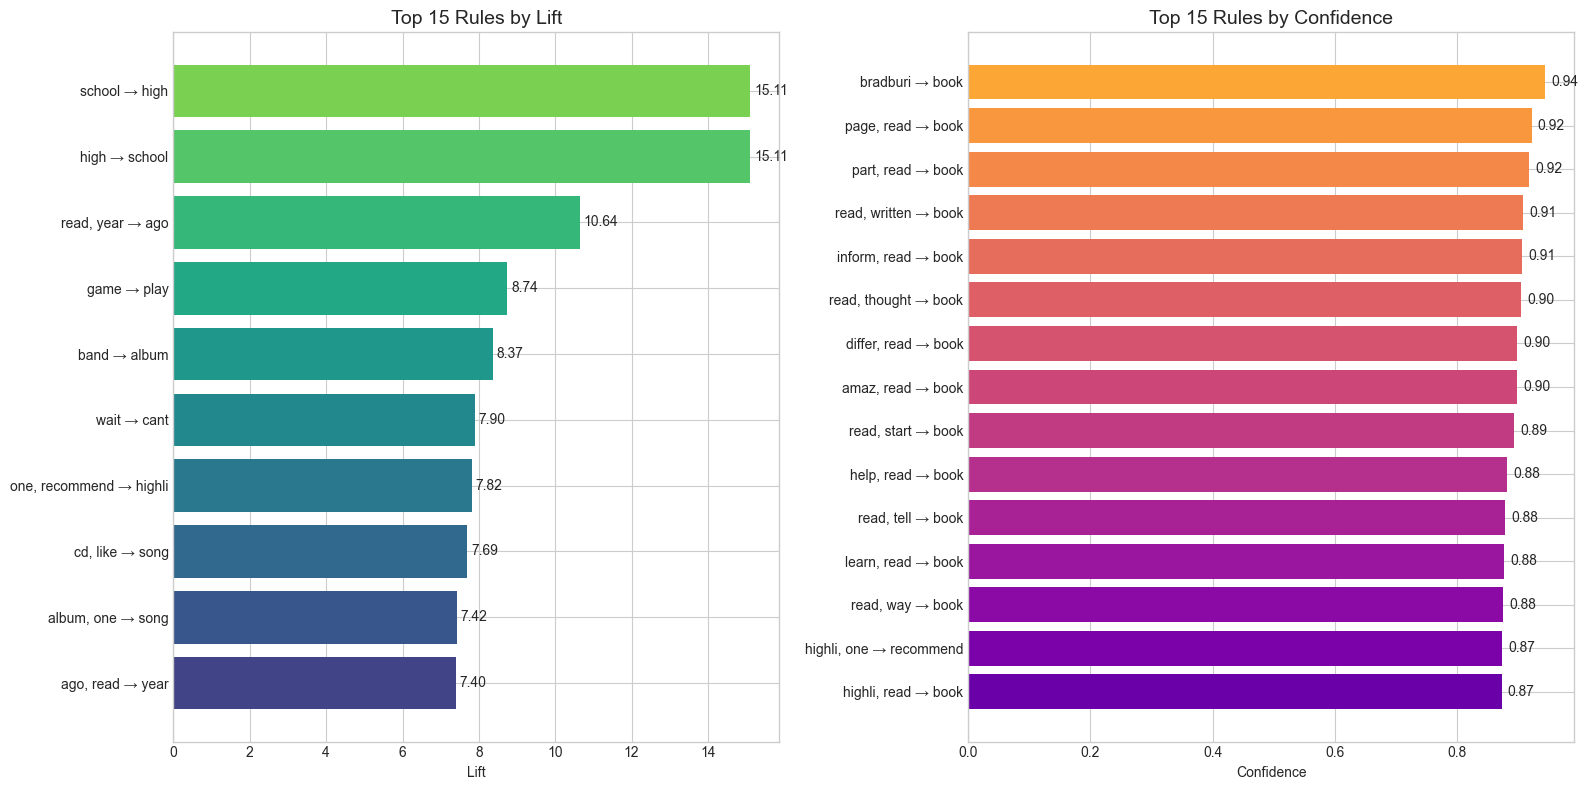

In [11]:
# Visualize top rules with bar chart
print("="*60)
print("VISUALIZING TOP RULES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top rules by lift
ax = axes[0]
plot_data = top_filtered.head(15).sort_values('lift')
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(plot_data)))
bars = ax.barh(range(len(plot_data)), plot_data['lift'].values, color=colors)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels([r[:40] + '...' if len(r) > 40 else r for r in plot_data['rule_str']])
ax.set_xlabel('Lift')
ax.set_title('Top 15 Rules by Lift', fontsize=14)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, plot_data['lift'].values)):
    ax.text(val + 0.1, i, f'{val:.2f}', va='center')

# Top rules by confidence
ax = axes[1]
plot_data = filtered_rules.nlargest(15, 'confidence').sort_values('confidence')
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(plot_data)))
bars = ax.barh(range(len(plot_data)), plot_data['confidence'].values, color=colors)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels([r[:40] + '...' if len(r) > 40 else r for r in plot_data['rule_str']])
ax.set_xlabel('Confidence')
ax.set_title('Top 15 Rules by Confidence', fontsize=14)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, plot_data['confidence'].values)):
    ax.text(val + 0.01, i, f'{val:.2f}', va='center')

plt.tight_layout()
plt.show()

RULE NETWORK GRAPH


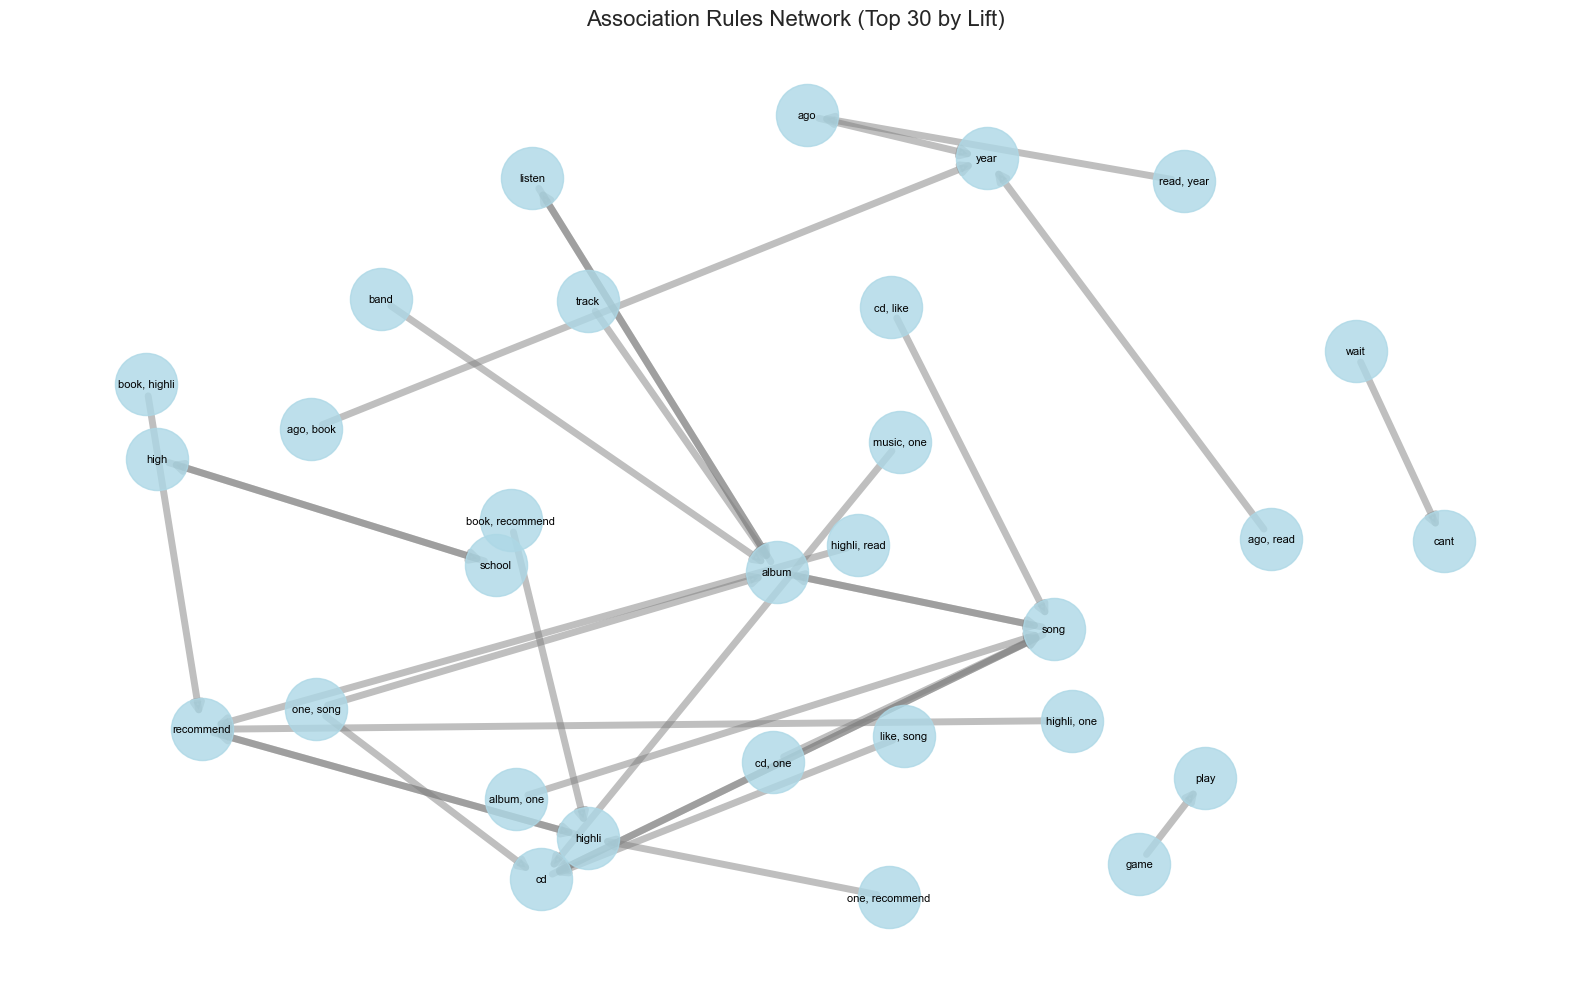

In [12]:
# Create network graph
print("="*60)
print("RULE NETWORK GRAPH")
print("="*60)

# Create graph
G = nx.DiGraph()

# Add edges from top rules
top_network_rules = filtered_rules.nlargest(30, 'lift')
for _, row in top_network_rules.iterrows():
    ant = row['antecedents_str']
    cons = row['consequents_str']
    lift = row['lift']
    
    G.add_node(ant)
    G.add_node(cons)
    G.add_edge(ant, cons, weight=lift)

# Draw graph
plt.figure(figsize=(16, 10))
pos = nx.spring_layout(G, k=2, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.8)

# Draw edges with width proportional to lift
edges = G.edges(data=True)
widths = [min(d['weight'] * 2, 5) for (_, _, d) in edges]
nx.draw_networkx_edges(G, pos, width=widths, alpha=0.5, edge_color='gray', 
                      arrows=True, arrowsize=15)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title('Association Rules Network (Top 30 by Lift)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

SUPPORT VS CONFIDENCE SCATTER PLOT


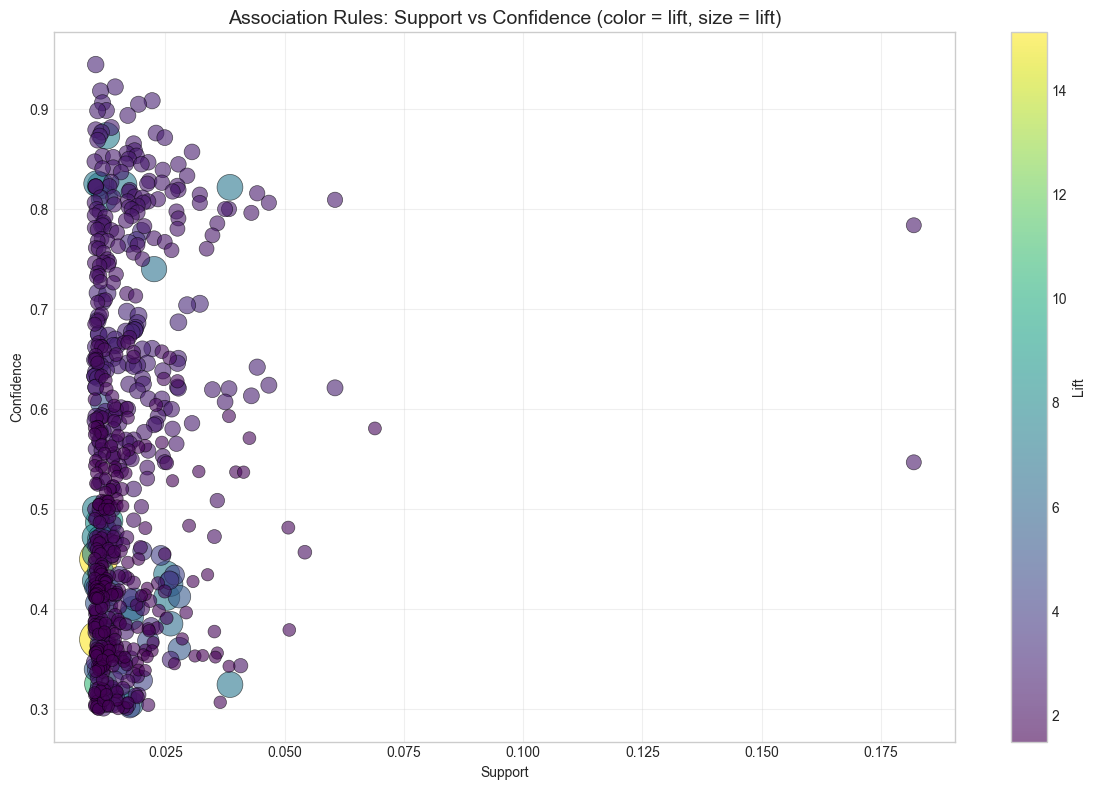


📊 Summary:
  • Total rules: 654
  • Average support: 0.0172
  • Average confidence: 0.5374
  • Average lift: 2.4655


In [13]:
# Scatter plot: Support vs Confidence
print("="*60)
print("SUPPORT VS CONFIDENCE SCATTER PLOT")
print("="*60)

plt.figure(figsize=(12, 8))

# Create scatter plot with lift as color
scatter = plt.scatter(
    filtered_rules['support'],
    filtered_rules['confidence'],
    c=filtered_rules['lift'],
    s=filtered_rules['lift'] * 50,
    alpha=0.6,
    cmap='viridis',
    edgecolors='black',
    linewidth=0.5
)

plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (color = lift, size = lift)', fontsize=14)

# Add grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Summary:")
print(f"  • Total rules: {len(filtered_rules):,}")
print(f"  • Average support: {filtered_rules['support'].mean():.4f}")
print(f"  • Average confidence: {filtered_rules['confidence'].mean():.4f}")
print(f"  • Average lift: {filtered_rules['lift'].mean():.4f}")

In [14]:
# Repeat for negative reviews
print("="*60)
print("RULES FOR NEGATIVE REVIEWS")
print("="*60)

# Get negative reviews
negative_df = df_train[df_train['label'] == 1].copy()
negative_texts = negative_df['review_clean'].tolist()

print(f"📊 Number of negative reviews: {len(negative_texts):,}")

# Prepare transactions
negative_transactions = [text.split() for text in negative_texts]

# Filter by frequency
word_freq_neg = {}
for trans in negative_transactions:
    for word in set(trans):
        word_freq_neg[word] = word_freq_neg.get(word, 0) + 1

top_words_neg = {word: freq for word, freq in word_freq_neg.items() if freq >= 5}
print(f"📊 Words with frequency >= 5: {len(top_words_neg):,}")

# Filter transactions
top_words_set_neg = set(top_words_neg.keys())
filtered_transactions_neg = []
for trans in negative_transactions:
    filtered = [word for word in trans if word in top_words_set_neg]
    if len(filtered) >= 2:
        filtered_transactions_neg.append(list(set(filtered)))

print(f"📊 Filtered transactions: {len(filtered_transactions_neg):,}")

# Encode
if len(filtered_transactions_neg) > 0:
    te_neg = TransactionEncoder()
    te_ary_neg = te_neg.fit(filtered_transactions_neg).transform(filtered_transactions_neg)
    onehot_df_neg = pd.DataFrame(te_ary_neg, columns=te_neg.columns_)
    
    # Mine itemsets
    frequent_itemsets_neg = fpgrowth(
        onehot_df_neg,
        min_support=0.01,
        use_colnames=True,
        max_len=3
    )
    
    print(f"📊 Found {len(frequent_itemsets_neg):,} frequent itemsets")
    
    # Generate rules
    if len(frequent_itemsets_neg) > 0:
        rules_neg = association_rules(
            frequent_itemsets_neg,
            metric='lift',
            min_threshold=1.2
        )
        rules_neg = rules_neg.sort_values('lift', ascending=False)
        
        print(f"📊 Generated {len(rules_neg):,} rules")
        
        # Show top rules
        print("\n📊 Top 5 rules for negative reviews:")
        top_neg = rules_neg.head(5)
        for i, (_, row) in enumerate(top_neg.iterrows(), 1):
            ant = ', '.join(list(row['antecedents']))
            cons = ', '.join(list(row['consequents']))
            print(f"\n{i:2d}. {ant} → {cons}")
            print(f"     lift={row['lift']:.2f}, confidence={row['confidence']:.2f}")

RULES FOR NEGATIVE REVIEWS
📊 Number of negative reviews: 5,097
📊 Words with frequency >= 5: 3,705
📊 Filtered transactions: 5,097


📊 Found 3,697 frequent itemsets
📊 Generated 6,546 rules

📊 Top 5 rules for negative reviews:

 1. special → movi, effect
     lift=25.36, confidence=0.46

 2. movi, effect → special
     lift=25.36, confidence=0.71

 3. special, movi → effect
     lift=23.56, confidence=0.73

 4. effect → special, movi
     lift=23.56, confidence=0.41

 5. effect → special
     lift=18.40, confidence=0.51


In [15]:
# Save results
print("="*60)
print("SAVING RESULTS")
print("="*60)

# Create output directories
os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

# Save rules to CSV
filtered_rules.to_csv('../outputs/tables/association_rules.csv', index=False)
if 'rules_neg' in locals() and len(rules_neg) > 0:
    rules_neg.to_csv('../outputs/tables/association_rules_negative.csv', index=False)

print(f"✅ Saved association rules to ../outputs/tables/")

# Save frequent itemsets
frequent_itemsets_fp.to_csv('../outputs/tables/frequent_itemsets.csv', index=False)

print(f"✅ Saved frequent itemsets")

print(f"\n📊 Association rules mining complete!")

SAVING RESULTS
✅ Saved association rules to ../outputs/tables/
✅ Saved frequent itemsets

📊 Association rules mining complete!
